In [ ]:
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import time
import tensorflow as tf  # Import TensorFlow
from tensorflow.keras import layers
from IPython import display

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (3).zip to archive (3).zip


In [ ]:
import zipfile

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  if fn.endswith('.zip'):
    with zipfile.ZipFile(fn, 'r') as zip_ref:
      zip_ref.extractall('./')
  else:
    print(f"File {fn} is not a zip file, skipping unzip.")


User uploaded file "archive (3).zip" with length 15529194 bytes


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1./255)
train_images = train_datagen.flow_from_directory(
    '/content/Hindi-MNIST/train',
    target_size=(32, 32),  # Adjust size as needed
    batch_size=32,
    class_mode='categorical'  # Use 'binary' for binary classification
)

Found 17000 images belonging to 10 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.model_selection import train_test_split

def load_and_preprocess_images(directory_path, image_size=(28, 28), batch_size=32, test_size=0.2):
    """
    Load and preprocess images for GAN training with train-test split

    Parameters:
    directory_path: str - Full path to your image directory
    image_size: tuple - Target size for images (width, height)
    batch_size: int - Batch size for training
    test_size: float - Proportion of dataset to use for testing (0.0 to 1.0)

    Returns:
    train_dataset, test_dataset: TF datasets for training and testing
    """
    # Create ImageDataGenerator
    datagen = ImageDataGenerator(
        rescale=1./255,
    )

    # Create generator
    generator = datagen.flow_from_directory(
        directory_path,
        target_size=image_size,
        batch_size=batch_size,
        class_mode=None,
        color_mode='grayscale',
        shuffle=True
    )

    # Calculate number of images
    num_images = generator.samples

    # Preallocate array
    images = np.zeros((num_images,) + image_size + (1,), dtype=np.float32)

    # Load all images
    for i in range(len(generator)):
        batch = generator[i]
        index_start = i * batch_size
        index_end = min((i + 1) * batch_size, num_images)
        images[index_start:index_end] = batch

    # Convert from [0,1] to [-1,1]
    images = images * 2 - 1

    # Split into train and test sets
    train_images, test_images = train_test_split(images, test_size=test_size, random_state=42)

    # Create TF datasets
    train_dataset = tf.data.Dataset.from_tensor_slices(train_images)\
        .shuffle(1000)\
        .batch(batch_size, drop_remainder=True)\
        .prefetch(tf.data.AUTOTUNE)

    test_dataset = tf.data.Dataset.from_tensor_slices(test_images)\
        .batch(batch_size, drop_remainder=True)\
        .prefetch(tf.data.AUTOTUNE)

    print(f"Training set shape: {train_images.shape}")
    print(f"Test set shape: {test_images.shape}")
    print(f"Value range: [{images.min():.2f}, {images.max():.2f}]")

    return train_dataset, test_dataset

# Example usage:
if __name__ == "__main__":
    # Replace this with your actual directory path
    # For example: "/home/user/data/devanagari_dataset"
    # Make sure your directory contains subdirectories for each class
    DIRECTORY_PATH = "/content/Hindi-MNIST"

    # Load and preprocess images with train-test split
    train_dataset, test_dataset = load_and_preprocess_images(
        directory_path=DIRECTORY_PATH,
        image_size=(28, 28),
        batch_size=32,
        test_size=0.2  # 80% training, 20% testing
    )

Found 20000 images belonging to 2 classes.
Training set shape: (16000, 28, 28, 1)
Test set shape: (4000, 28, 28, 1)
Value range: [-1.00, 1.00]


In [ ]:
# Function to build the generator model
def make_generator_model():
    model = tf.keras.Sequential()

    # First layer: Dense layer to project the input noise vector (latent space) to a higher-dimensional space
    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(100,)))
    # Batch normalization helps stabilize training by normalizing the outputs of the previous layer
    model.add(layers.BatchNormalization())
    # LeakyReLU activation to allow a small gradient when the unit is not active
    model.add(layers.LeakyReLU())

    # Reshape the output to a 7x7x256 tensor
    model.add(layers.Reshape((7, 7, 256)))
    # The output shape is (batch_size, 7, 7, 256)
    # assert model.output_shape == (None, 7, 7, 256)

    # First transposed convolutional layer
    # Upsamples the input to a larger feature map
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    # Output shape: (batch_size, 7, 7, 128)
    # assert model.output_shape == (None, 7, 7, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Second transposed convolutional layer
    # Upsamples to 14x14
    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    # Output shape: (batch_size, 14, 14, 64)
    # assert model.output_shape == (None, 14, 14, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Final transposed convolutional layer
    # Upsamples to 28x28, matches the MNIST image size
    # tanh activation scales the output to [-1, 1]
    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh')) # normalised image.
    # use this normalised image into descriminator again.
    # if you are not using tanh, hten you have to normalise before giving it to discriminator.
    # Output shape: (batch_size, 28, 28, 1)
    # assert model.output_shape == (None, 28, 28, 1) # should be the same as the real data shape

    return model

# Instantiate the generator model
generator = make_generator_model()
generator.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 12544)               │       1,254,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 12544)               │          50,176 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose (Conv2DTranspose)   │ (None, 7, 7, 128)           │         819,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 7, 7, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose) │ (None, 14, 14, 64)          │         204,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_2 (Conv2DTranspose) │ (None, 28, 28, 1)           │           1,600 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

In [ ]:
# Generate a sample image to test the generator
noise = tf.random.normal([1, 100])  # Generate random noise vector
print(noise)

tf.Tensor(
[[ 0.36212385 -2.0573533  -1.0578052  -0.4601298  -2.39048    -0.96023285
   0.7808438   0.40666044 -2.3789332   0.4016662   0.62211484  1.8010279
   0.49949914  0.0695582   0.9551122   0.79353076 -0.3366215   1.9439392
   0.01781113 -1.0948293   1.1049016  -0.975681    1.1219356  -0.624896
  -0.0188836   0.1402571  -0.8022702  -1.9146423   1.0201629  -0.63689053
   0.2987895   2.6538594   1.2278979  -0.48433506  0.08616909 -0.53318954
  -0.11581032 -0.18187326  0.2655899   0.52676475 -1.8224024  -0.39203393
   0.433098    1.766402   -0.29529518 -0.23367032 -1.041395   -0.8966072
  -0.64303195  0.1065929  -1.015993   -0.23241025  0.64783436 -1.1741275
  -0.3845627   0.37341487 -1.1763701   0.41657826  1.3154452  -0.37237212
  -0.7789655   0.08875668 -0.31467187  1.4585911  -0.31232154 -1.7085849
  -0.8683193   0.8097054   0.7192082  -0.7691533  -0.66352403 -0.02272335
   0.49686256  0.25627923 -1.3212866  -1.3318887  -1.1051241  -0.36258256
   1.6452447  -0.10725541  0.09525

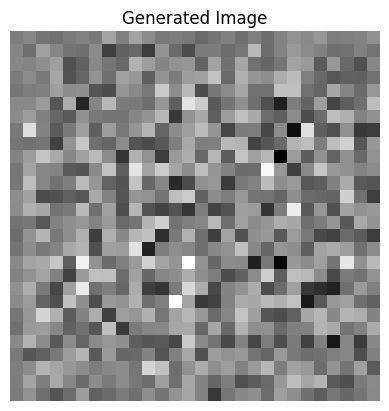

In [ ]:
# Generate a sample image to test the generator
noise = tf.random.normal([1, 100])  # Generate random noise vector
generated_image = generator(noise, training=False)  # Generate image from noise

# Display the generated image
plt.imshow(generated_image[0, :, :, 0], cmap='gray')
plt.title("Generated Image")
plt.axis('off')
plt.show()

In [ ]:
# Function to build the discriminator model
def make_discriminator_model():
    model = tf.keras.Sequential()

    # First convolutional layer
    # Downsamples the input image
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                            input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    # Dropout helps prevent overfitting by randomly setting inputs to zero during training
    model.add(layers.Dropout(0.3))

    # Second convolutional layer
    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Flatten the output and add a final dense layer for classification
    model.add(layers.Flatten())
    # Output layer without activation function (logits)
    model.add(layers.Dense(1)) # sigmoid activaiton funcution becuase we have only real or fake images.

    return model

# Instantiate the discriminator model
discriminator = make_discriminator_model()
discriminator.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 14, 14, 64)          │           1,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 7, 7, 128)           │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_4 (LeakyReLU)            │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │           6,273 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Test the discriminator on the generated image
decision = discriminator(generated_image)
print("Discriminator output:", decision)

Discriminator output: tf.Tensor([[-0.00125911]], shape=(1, 1), dtype=float32)


In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [ ]:
# Discriminator loss function
def discriminator_loss(real_output, fake_output):
    # Compute loss on real images (should be classified as 1)
    real_loss = cross_entropy(tf.ones_like(real_output), real_output) # class 1 for real
    # Compute loss on fake images (should be classified as 0)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output) # class 0 fro fake
    # Total discriminator loss
    total_loss = real_loss + fake_loss
    return total_loss

In [ ]:
# Generator loss function
def generator_loss(fake_output):
    # Generator tries to fool the discriminator, so we want the fake images to be classified as real (1)
    return cross_entropy(tf.ones_like(fake_output), fake_output) # classifying 1

In [ ]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [ ]:
# Set up checkpointing to save the models during training
checkpoint_dir = './training_checkpoints'  # Directory to save checkpoints
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")

# Ensure the checkpoint directory exists
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)

# Create a checkpoint object to manage all the objects to be saved
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

In [ ]:
# Set training parameters
EPOCHS = 100               # Number of epochs to train
noise_dim = 100           # Dimension of the noise vector (latent space)
num_examples_to_generate = 16  # Number of examples to generate for visualization
batch_size = 256

# Seed for generating images to visualize progress
# Using the same seed allows us to see how the generated images evolve over time
seed = tf.random.normal([num_examples_to_generate, noise_dim])

In [ ]:
noise = tf.random.normal([batch_size, noise_dim])
noise

<tf.Tensor: shape=(256, 100), dtype=float32, numpy=
array([[ 0.32971   , -0.51799715, -0.42170042, ..., -0.44061482,
        -1.0615085 , -2.307415  ],
       [-0.21154028,  2.4762535 ,  0.2327569 , ..., -0.6030343 ,
        -1.827707  , -0.264429  ],
       [ 0.03135278,  1.5313342 ,  0.55060387, ...,  0.0165106 ,
         0.56214535, -0.3179688 ],
       ...,
       [ 0.01124339, -0.9922884 ,  0.29328126, ..., -0.05935534,
        -0.34942853, -1.5919474 ],
       [ 0.37128463, -0.04378246, -1.4446473 , ...,  0.29611206,
        -2.0214603 ,  0.23246829],
       [-1.6229265 , -0.04821476, -0.32502857, ...,  1.6533276 ,
         0.87076473,  0.8447883 ]], dtype=float32)>

In [ ]:
generated_images = generator(noise, training=True)
generated_images.shape

TensorShape([256, 28, 28, 1])

In [ ]:
# Define the training step function
# Use @tf.function to compile the function for faster execution
@tf.function
def train_step(images):
    # Generate random noise for input to the generator
    noise = tf.random.normal([batch_size, noise_dim])

    # Record operations for automatic differentiation
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Generate fake images from the noise
        generated_images = generator(noise, training=True)

        # Get the discriminator's predictions on real and fake images
        real_output = discriminator(images, training=True)
        # fake_output contains the discriminator's predictions on the fake images.
        fake_output = discriminator(generated_images, training=True)

        #   Explanation:
        '''generator_loss is a function that computes the loss for the generator.
            It takes fake_output as input, which are the discriminator's predictions on fake images.
            gen_loss is the calculated loss value for the generator.
            Purpose:
            The generator wants to fool the discriminator.
            The loss measures how well the generator is doing in making the discriminator believe the fake images are real.
            '''

        # Calculate losses for both generator and discriminator
        gen_loss = generator_loss(fake_output)

        '''
        Explanation:
        discriminator_loss is a function that computes the loss for the discriminator.
        It takes two inputs:
        real_output: Discriminator's predictions on real images.
        fake_output: Discriminator's predictions on fake images.
        disc_loss is the calculated loss value for the discriminator.
        Purpose:
        The discriminator aims to correctly classify real and fake images.
        The loss measures how well the discriminator distinguishes between real and fake data.
        '''
        disc_loss = discriminator_loss(real_output, fake_output)

    # Calculate gradients for generator and discriminator
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # Apply gradients to update the weights of generator and discriminator
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [ ]:
# Function to generate and save images during training
def generate_and_save_images(model, epoch, test_input):
    # Note: Set training=False to ensure that all layers run in inference mode (e.g., dropout and batchnorm)
    predictions = model(test_input, training=False)

    # Rescale images from [-1, 1] to [0, 1] for display
    predictions = (predictions + 1) / 2.0

    # Set up the plot
    fig = plt.figure(figsize=(4, 4))

    # Generate subplots for each image
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0], cmap='gray')
        plt.axis('off')

    # Save the figure
    plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
    plt.show()

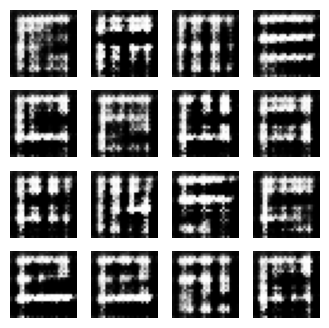

Time for epoch 1 is 26.17 sec


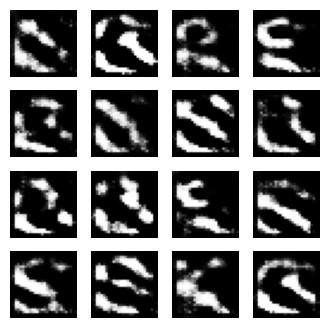

Time for epoch 2 is 19.18 sec


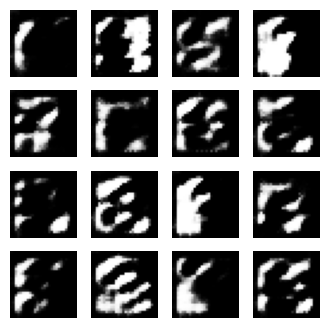

Time for epoch 3 is 19.46 sec


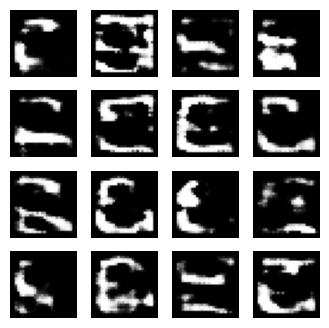

Time for epoch 4 is 20.01 sec


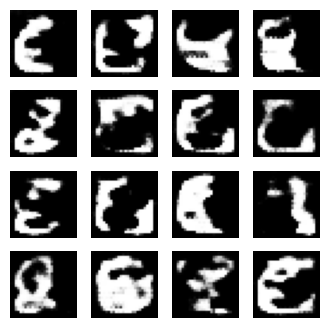

Time for epoch 5 is 20.19 sec


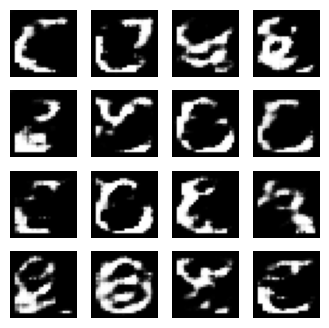

Time for epoch 6 is 20.43 sec


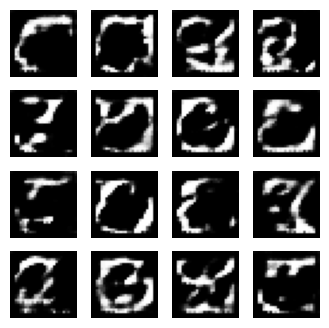

Time for epoch 7 is 20.54 sec


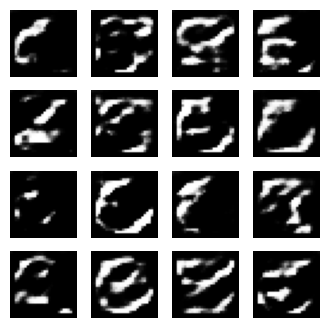

Time for epoch 8 is 20.98 sec


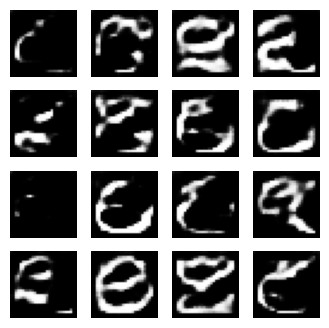

Time for epoch 9 is 20.77 sec


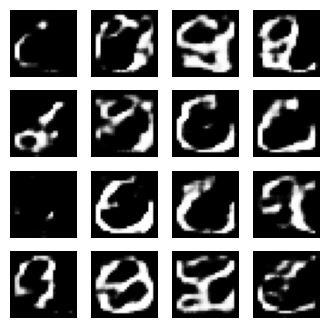

Time for epoch 10 is 20.85 sec


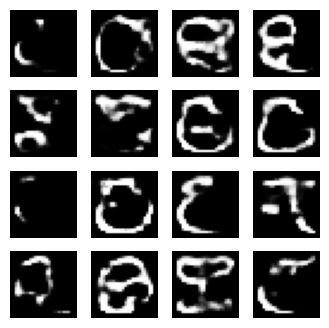

Time for epoch 11 is 20.80 sec


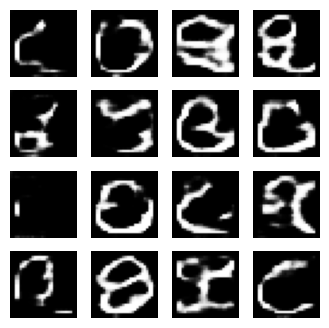

Time for epoch 12 is 20.70 sec


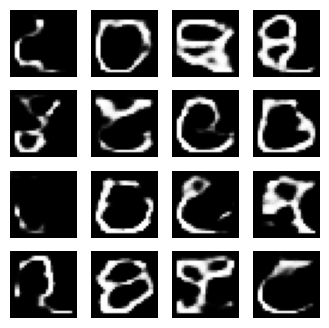

Time for epoch 13 is 20.71 sec


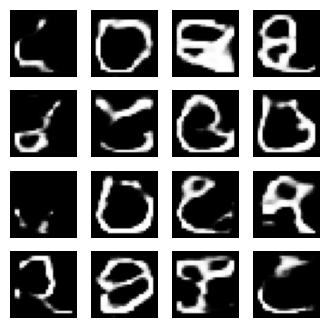

Time for epoch 14 is 20.71 sec


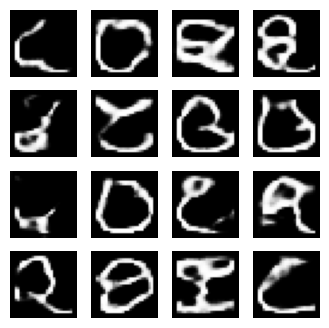

Time for epoch 15 is 21.15 sec


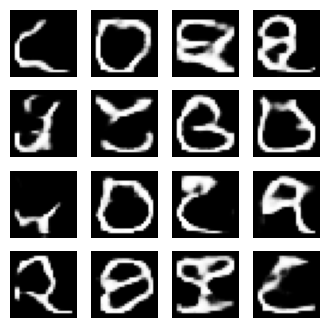

Time for epoch 16 is 20.74 sec


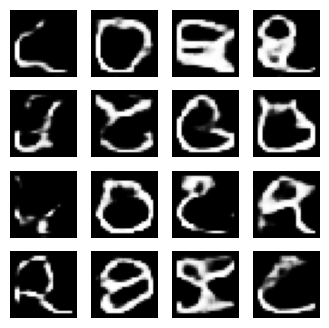

Time for epoch 17 is 20.65 sec


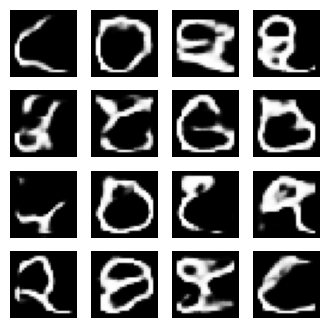

Time for epoch 18 is 20.76 sec


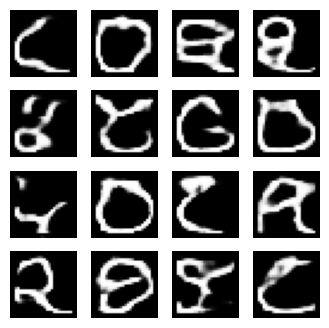

Time for epoch 19 is 20.68 sec


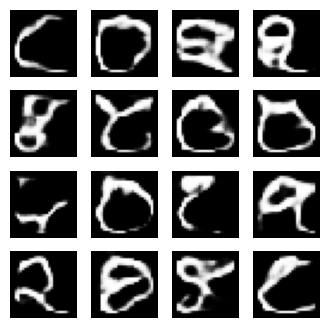

Time for epoch 20 is 20.94 sec


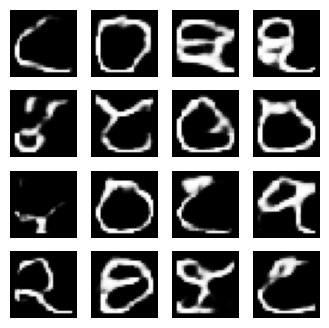

Time for epoch 21 is 20.79 sec


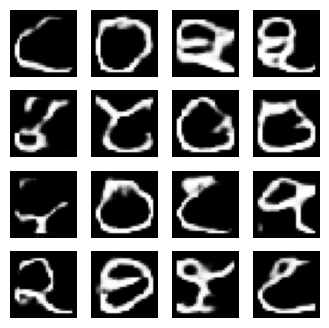

Time for epoch 22 is 20.66 sec


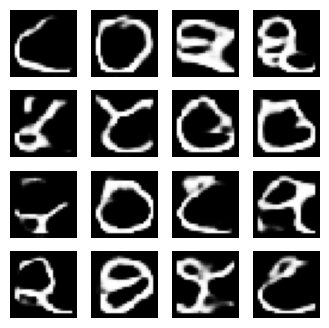

Time for epoch 23 is 20.65 sec


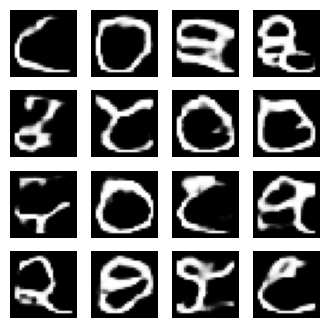

Time for epoch 24 is 20.86 sec


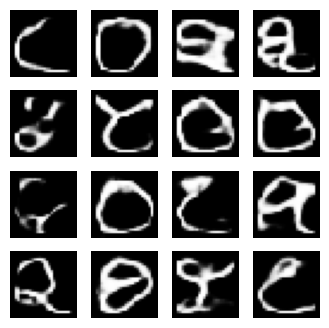

Time for epoch 25 is 20.70 sec


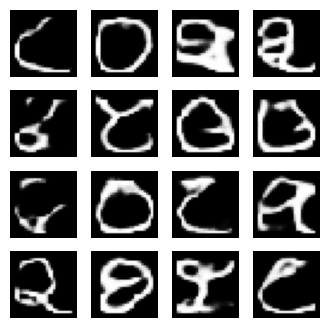

Time for epoch 26 is 20.94 sec


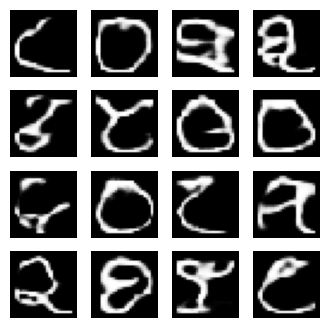

Time for epoch 27 is 20.60 sec


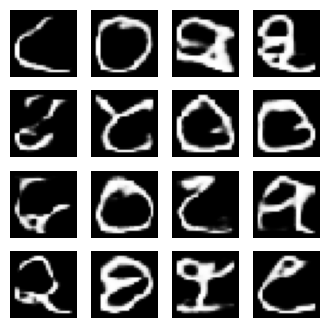

Time for epoch 28 is 20.64 sec


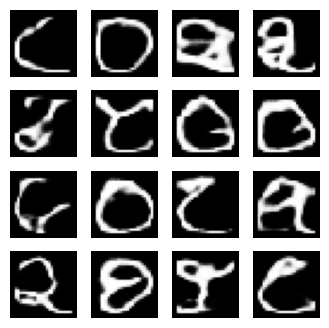

Time for epoch 29 is 20.67 sec


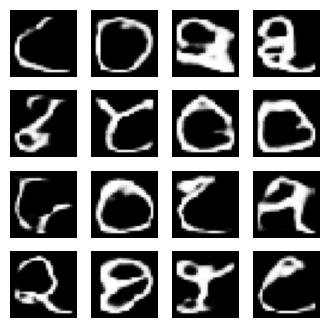

Time for epoch 30 is 20.86 sec


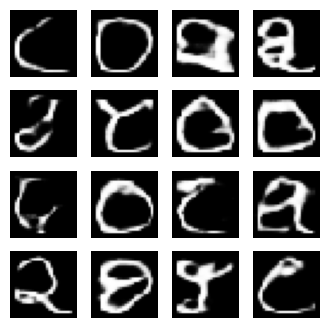

Time for epoch 31 is 20.97 sec


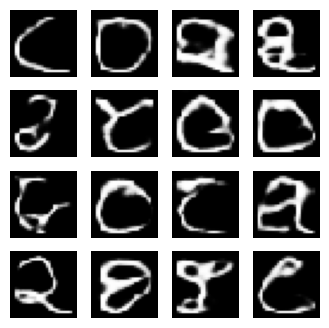

Time for epoch 32 is 20.74 sec


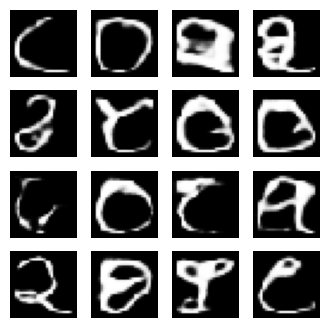

Time for epoch 33 is 20.71 sec


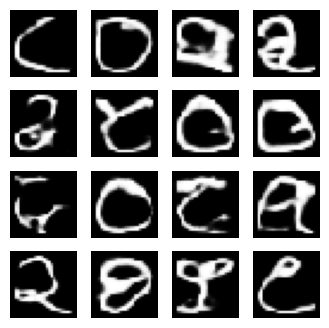

Time for epoch 34 is 20.69 sec


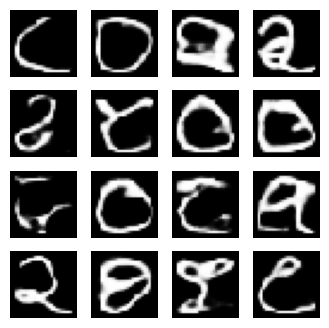

Time for epoch 35 is 20.69 sec


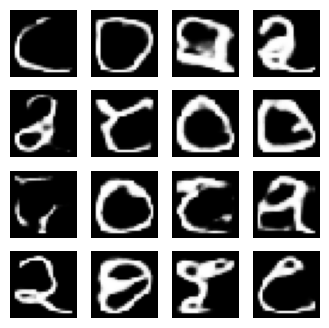

Time for epoch 36 is 20.97 sec


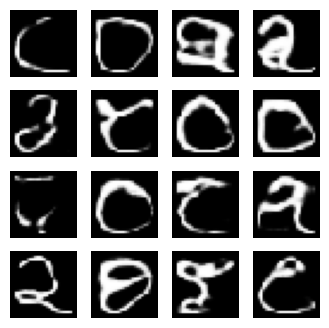

Time for epoch 37 is 20.79 sec


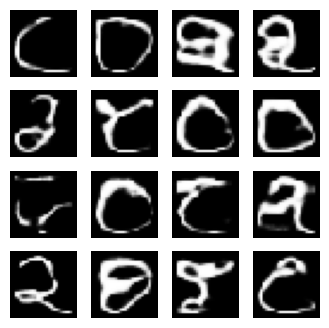

Time for epoch 38 is 20.69 sec


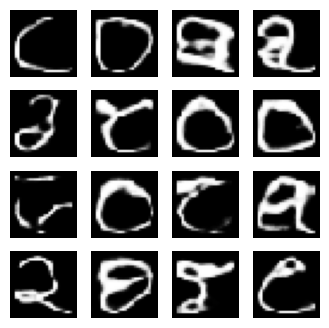

Time for epoch 39 is 20.69 sec


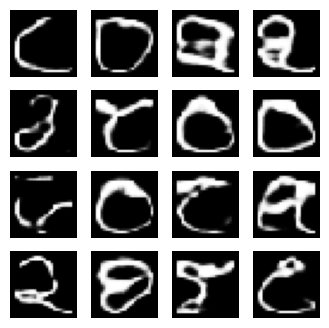

Time for epoch 40 is 20.82 sec


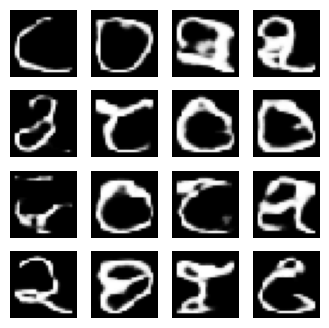

Time for epoch 41 is 20.68 sec


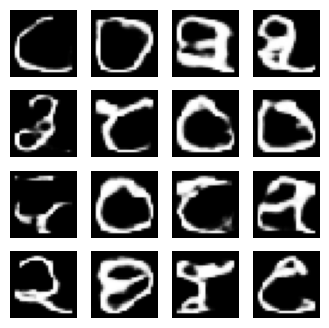

Time for epoch 42 is 20.97 sec


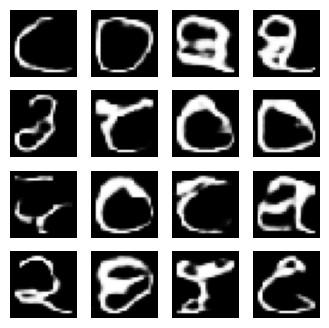

Time for epoch 43 is 20.69 sec


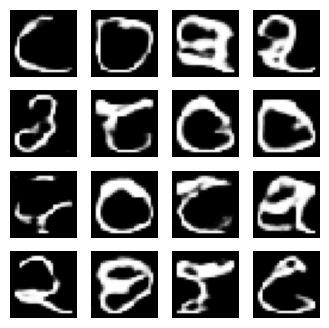

Time for epoch 44 is 20.88 sec


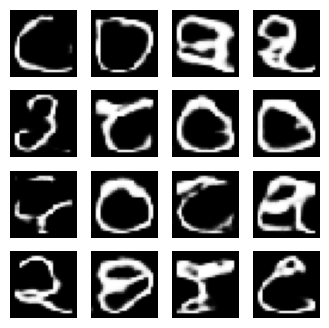

Time for epoch 45 is 20.83 sec


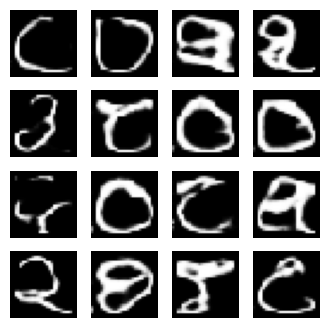

Time for epoch 46 is 20.67 sec


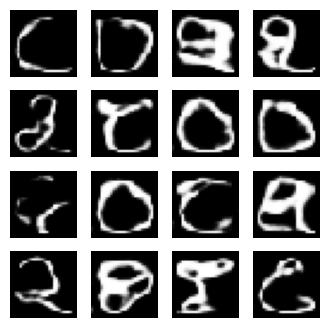

Time for epoch 47 is 20.95 sec


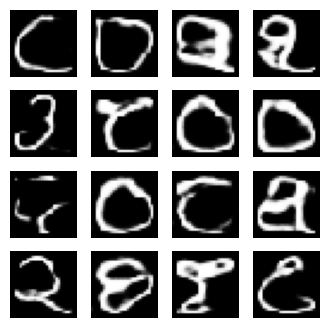

Time for epoch 48 is 20.69 sec


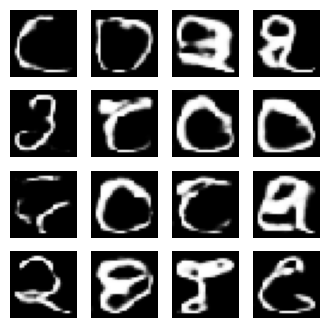

Time for epoch 49 is 20.67 sec


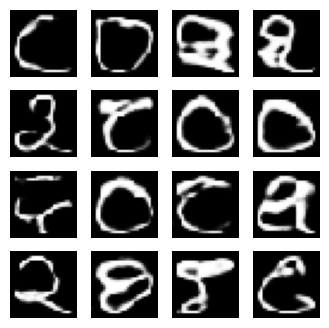

Time for epoch 50 is 20.90 sec


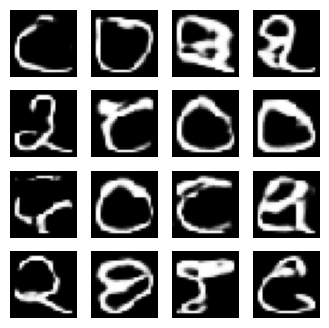

Time for epoch 51 is 20.70 sec


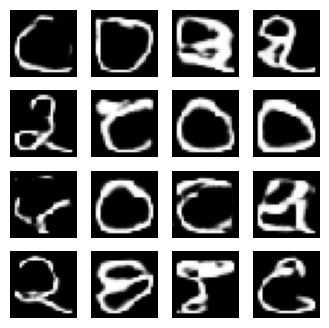

Time for epoch 52 is 20.97 sec


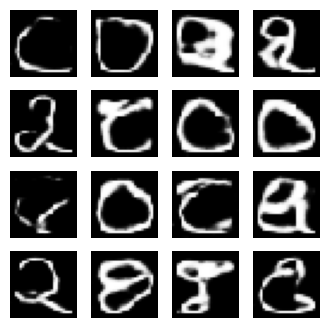

Time for epoch 53 is 20.94 sec


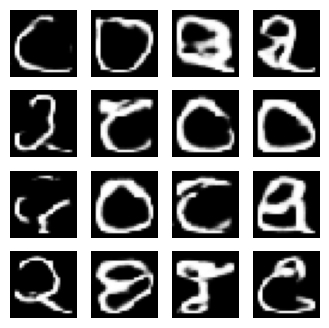

Time for epoch 54 is 20.72 sec


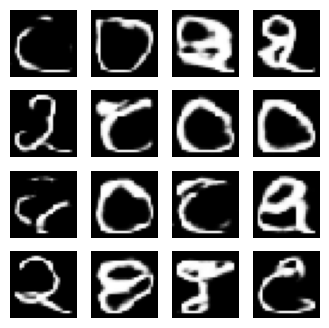

Time for epoch 55 is 20.69 sec


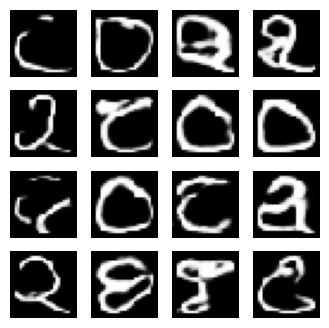

Time for epoch 56 is 20.75 sec


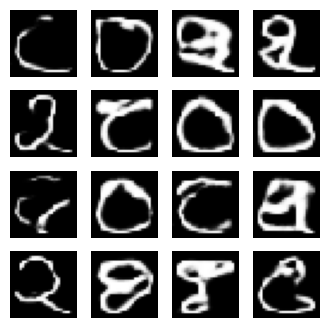

Time for epoch 57 is 20.63 sec


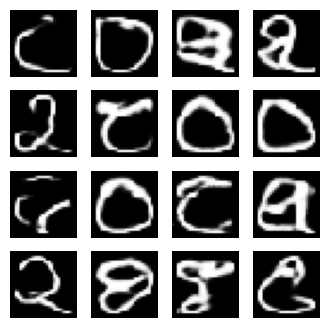

Time for epoch 58 is 20.92 sec


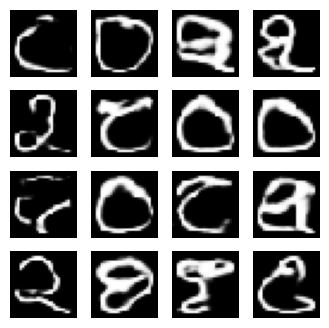

Time for epoch 59 is 20.68 sec


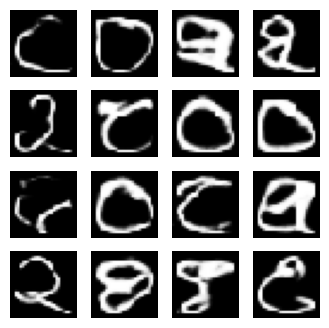

Time for epoch 60 is 20.76 sec


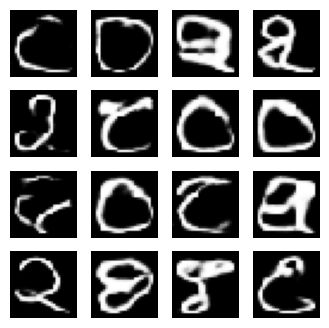

Time for epoch 61 is 20.64 sec


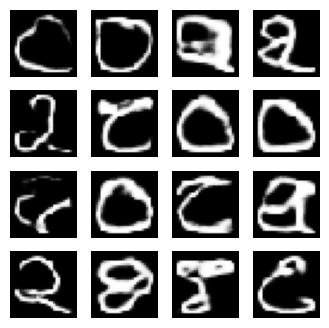

Time for epoch 62 is 20.69 sec


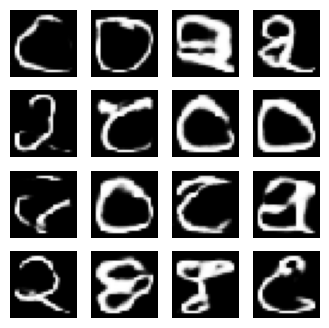

Time for epoch 63 is 21.00 sec


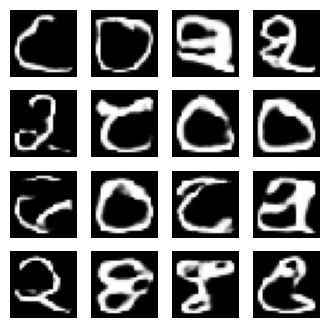

Time for epoch 64 is 20.72 sec


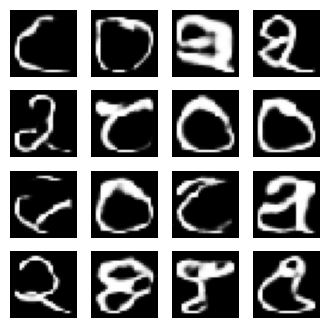

Time for epoch 65 is 20.72 sec


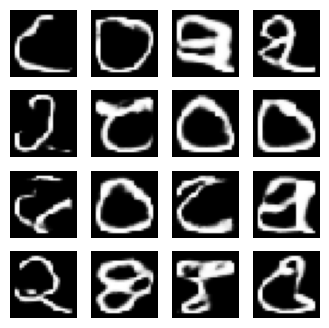

Time for epoch 66 is 20.89 sec


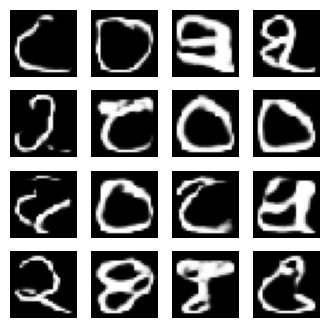

Time for epoch 67 is 20.72 sec


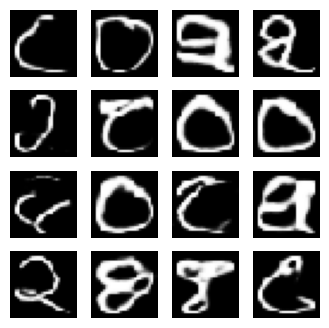

Time for epoch 68 is 20.95 sec


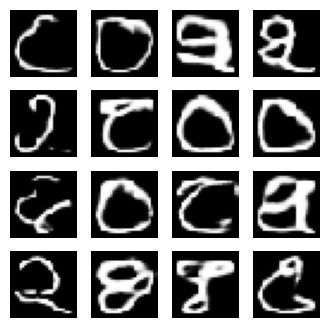

Time for epoch 69 is 20.78 sec


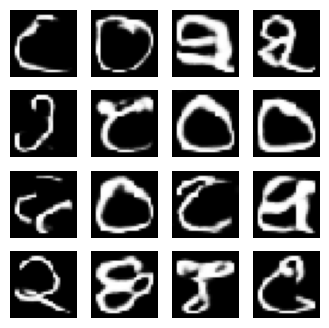

Time for epoch 70 is 20.64 sec


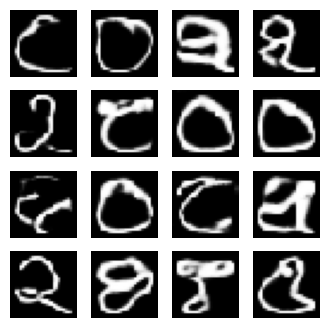

Time for epoch 71 is 20.64 sec


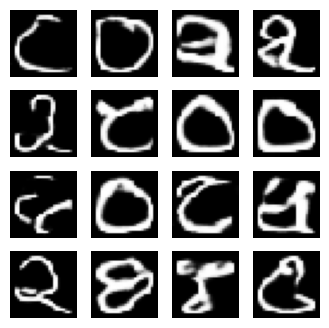

Time for epoch 72 is 20.82 sec


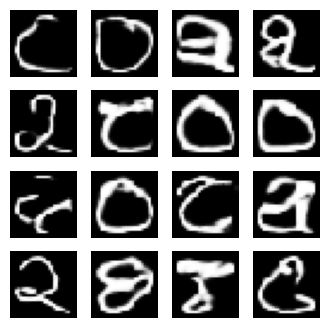

Time for epoch 73 is 20.67 sec


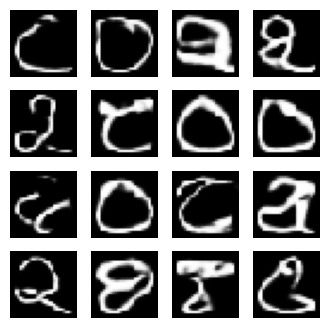

Time for epoch 74 is 20.95 sec


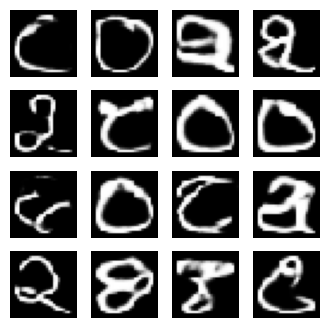

Time for epoch 75 is 20.83 sec


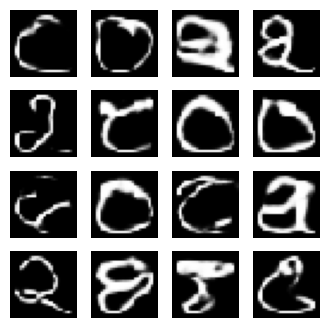

Time for epoch 76 is 20.71 sec


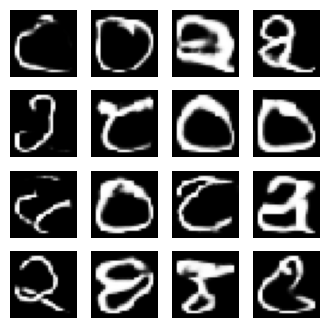

Time for epoch 77 is 20.71 sec


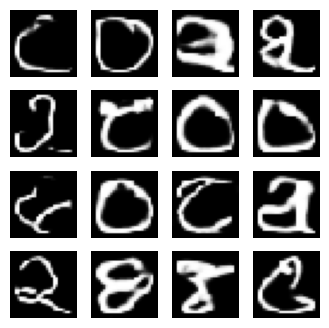

Time for epoch 78 is 20.68 sec


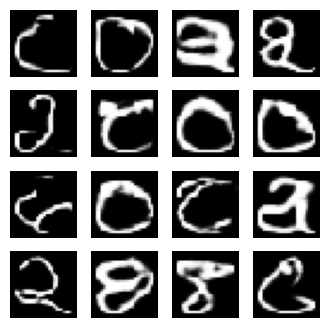

Time for epoch 79 is 20.90 sec


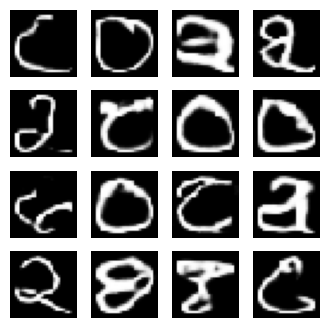

Time for epoch 80 is 20.62 sec


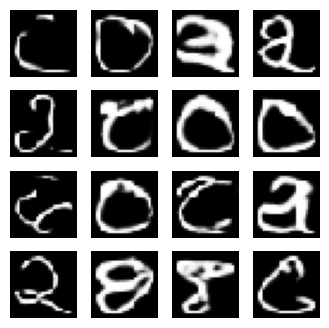

Time for epoch 81 is 20.67 sec


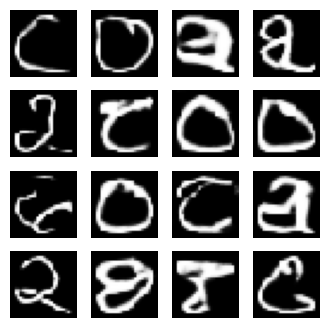

Time for epoch 82 is 20.85 sec


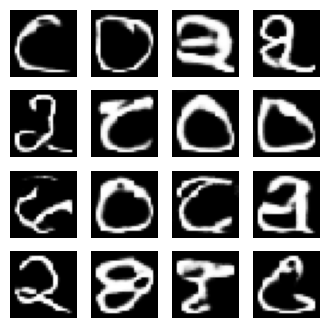

Time for epoch 83 is 20.70 sec


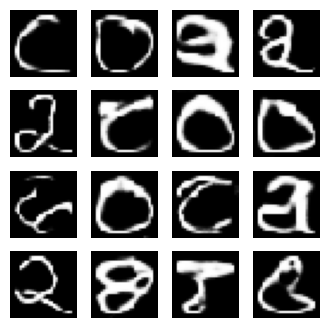

Time for epoch 84 is 20.95 sec


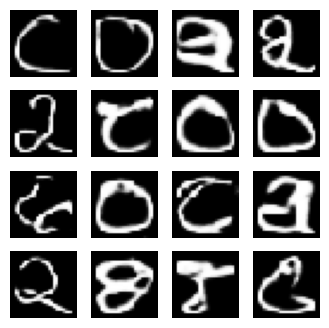

Time for epoch 85 is 20.85 sec


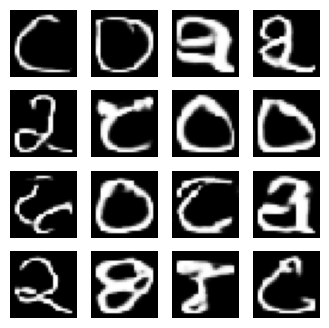

Time for epoch 86 is 20.68 sec


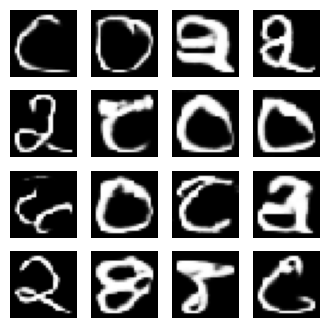

Time for epoch 87 is 20.70 sec


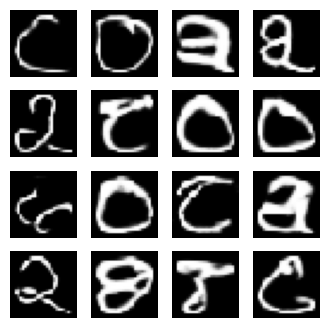

Time for epoch 88 is 20.88 sec


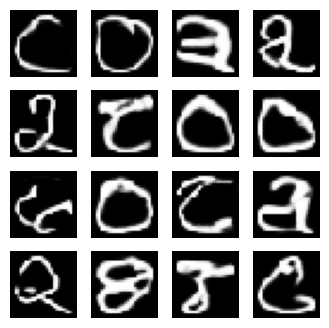

Time for epoch 89 is 20.72 sec


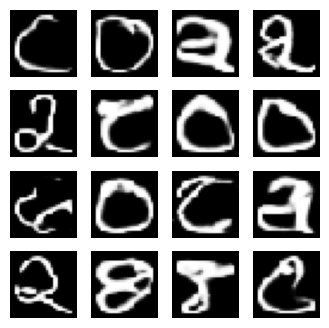

Time for epoch 90 is 21.17 sec


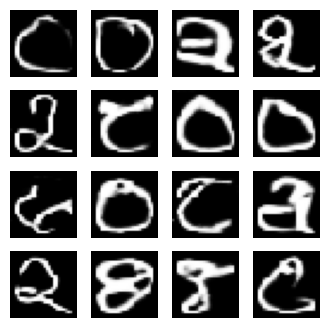

Time for epoch 91 is 20.72 sec


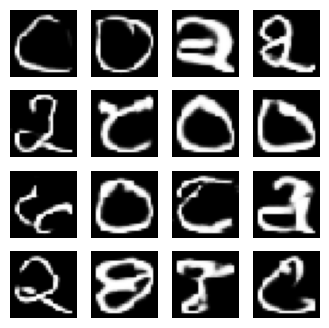

Time for epoch 92 is 20.71 sec


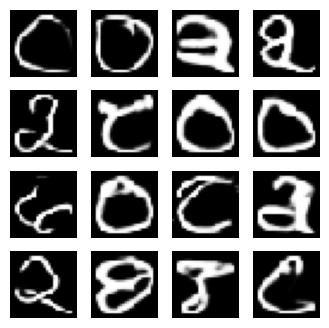

Time for epoch 93 is 20.70 sec


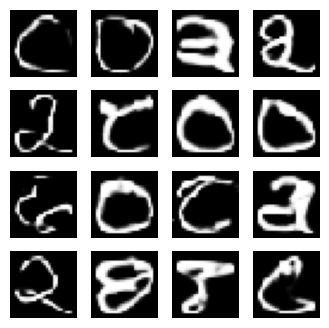

Time for epoch 94 is 20.74 sec


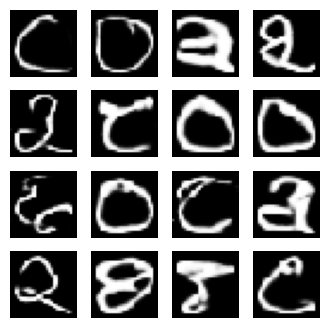

Time for epoch 95 is 20.99 sec


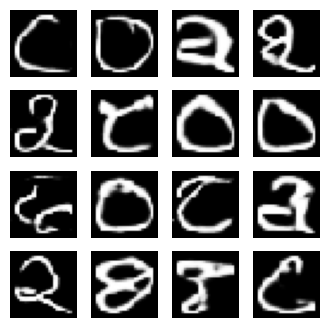

Time for epoch 96 is 20.74 sec


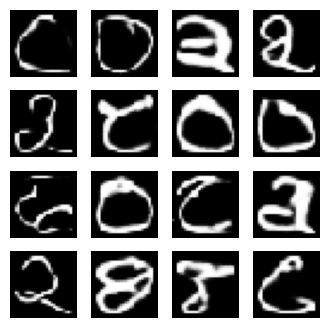

Time for epoch 97 is 20.71 sec


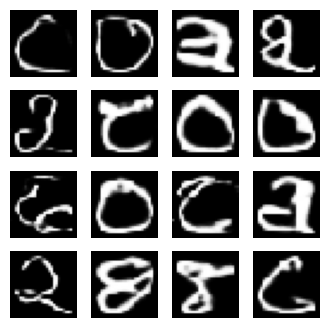

Time for epoch 98 is 20.80 sec


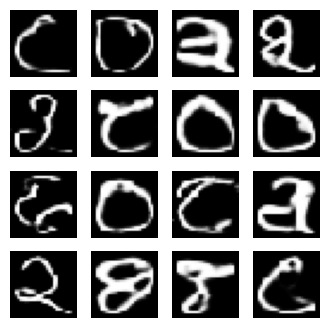

Time for epoch 99 is 20.68 sec


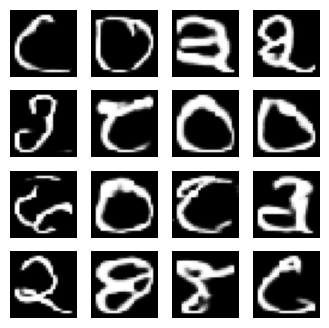

Time for epoch 100 is 20.96 sec


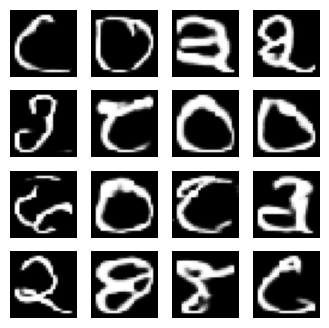

In [ ]:
# Training function to run the training loop
def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()

        # Iterate over each batch of images
        for image_batch in dataset:
            train_step(image_batch)

        # Clear the output to display progress
        # display.clear_output(wait=True)
        # Generate and save images to visualize progress
        generate_and_save_images(generator, epoch + 1, seed)

        # Save the model every 15 epochs
        if (epoch + 1) % 15 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

        print('Time for epoch {} is {:.2f} sec'.format(epoch + 1, time.time() - start))

    # Generate images after the final epoch
    # display.clear_output(wait=True)
    generate_and_save_images(generator, epochs, seed)

# Start training the GAN
train(train_dataset, EPOCHS)

In [22]:
# Create an animated GIF of the generated images over epochs
anim_file = 'gan.gif'

with imageio.get_writer(anim_file, mode='I') as writer:
    # Get the list of image files generated during training
    filenames = glob.glob('image_at_epoch_*.png')
    filenames = sorted(filenames)
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)
    # Append the last image multiple times for a pause at the end
    for _ in range(10):
        writer.append_data(image)

<ipython-input-22-283ca4287b8c>:9: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)
